<a href="https://colab.research.google.com/github/wnstj1126-debug/-/blob/main/OnlineSim_FEMTO_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 온라인 시뮬레이션 — FEMTO 스트리밍 검증 v1

**트랙:** `field_iis3dwb/` (IMS/FEMTO 검증 트랙과 독립)

**단계:** 1단계 — 온라인 시뮬레이션 (Colab)

## 전체 로드맵

| 단계 | 내용 | 환경 | 상태 |
|:---:|:---|:---:|:---:|
| **1** | **온라인 시뮬레이션 — FEMTO로 스트리밍 검증** | **Colab** | **← 지금** |
| 2 | 현장 수집 준비물 확정 | - | 예정 |
| 3 | 현장 PoC 데이터 수집 | 현장 PC+보드 | 예정 |
| 4 | 실물 데이터로 파라미터 재튜닝 | Colab | 예정 |
| 5 | MCU 이식 및 제품화 | STM32CubeIDE | 예정 |

## 이번 검증 목표

오프라인 검증(전체 데이터 한 번에)과 온라인 시뮬레이션(1윈도우씩 순차)이 **같은 결과**를 내는가 확인.

> FEMTO Bearing1_1 오프라인 기준: 수명 40.7% 경보, 오경보 0건  
> 온라인에서도 비슷한 시점에 경보 + 등록 구간 오경보 0건 → **"미래 정보 없이 실시간으로도 작동"** 증명

## 핵심 최적화 파라미터

| 파라미터 | 의미 | 현장 의미 |
|:---|:---|:---|
| `BASELINE_WINDOWS` | 등록에 쓸 윈도우 수 | **설치 후 몇 초/분 기다릴지** |
| `K` | 임계배수 | 오경보↔민감도 트레이드오프 |
| `CONSEC` | 연속 초과 횟수 | 단발 스파이크 억제 강도 |

**실행 순서:** `A` → **런타임재시작** → `A-2` → `S0(클래스)` → `S1(단일)` → `S2(스윕)` → `S3(전베어링)` → `S4(판정)`

# ============================================================
# 셀 A — 한글 폰트 설치 (최초 1회. 설치 후 런타임 재시작 필수)
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null
!fc-cache -fv > /dev/null
import subprocess
r = subprocess.run(['ls', '/usr/share/fonts/truetype/nanum/'], capture_output=True, text=True)
print(r.stdout)
print('★ 런타임 재시작 후 셀A-2부터 실행 (런타임 > 세션 다시 시작)')

/tmp/ipykernel_1637/3642458540.py:13: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


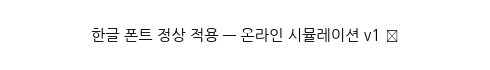

In [1]:
# ============================================================
# 셀 A-2 — 한글 폰트 적용 (런타임 재시작 후 매번 실행)
# ============================================================
import os, matplotlib.pyplot as plt, matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False
    fig, ax = plt.subplots(figsize=(5, 0.8))
    ax.text(0.5, 0.5, '한글 폰트 정상 적용 — 온라인 시뮬레이션 v1 ✅',
            ha='center', va='center', fontsize=11)
    ax.axis('off'); plt.tight_layout(); plt.show(); plt.close()
else:
    print('폰트 없음 → 셀A 실행 후 런타임 재시작')

In [2]:
# ============================================================
# 셀 S0 — 라이브러리 & FieldBaselineDetector 클래스 정의
# (FieldPipeline_IIS3DWB_v1.ipynb 의 P1과 동일 — 독립 실행 가능)
# ============================================================
import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
    plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount('/content/drive')

# ---- 경로 ----
FEMTO_BASE = '/content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing'
OUT_DIR    = '/content/drive/My Drive/Colab Notebooks/field_iis3dwb/'
os.makedirs(OUT_DIR, exist_ok=True)

# ---- IIS3DWB 사양 ----
FS_IIS3DWB = 26667
FEMTO_FS   = 25600   # FEMTO 실제 샘플링레이트
SIGNAL_COL = 4       # 열4 = H축 가속도

# ---- 공통 함수 ----
def load_femto(fp):
    try:
        arr = np.loadtxt(fp, delimiter=',')
        if arr.ndim == 2 and arr.shape[1] == 6: return arr
    except Exception: pass
    return np.loadtxt(fp, delimiter=';')

def extract_features(sig, fs=FEMTO_FS):
    x = sig.astype(np.float64)
    rms   = np.sqrt(np.mean(x**2))
    peak  = np.max(np.abs(x))
    crest = peak / (rms + 1e-12)
    kurt  = kurtosis(x)
    sk    = skew(x)
    p2p   = np.ptp(x)
    std   = np.std(x)
    env   = np.abs(hilbert(x))
    env_rms = np.sqrt(np.mean((env - env.mean())**2))
    fft_mag = np.abs(np.fft.rfft(x))
    freqs   = np.fft.rfftfreq(len(x), 1/fs)
    hf      = np.sum(fft_mag[freqs > 2000]**2) / (np.sum(fft_mag**2) + 1e-12)
    return np.array([rms, peak, crest, kurt, sk, p2p, std, env_rms, hf])

FEATURE_NAMES = ['RMS','Peak','Crest','Kurtosis','Skew','P2P','Std','EnvRMS','HF_ratio']


class FieldBaselineDetector:
    """
    현장 설치형 이상 탐지기 — 온라인 실시간 구조
    push_window() 1회 = 1개 윈도우 신호 처리
    처음 baseline_windows 번: REGISTERING (베이스라인 수집)
    이후: MONITORING (실시간 판정)
    """
    def __init__(self, K=6, consec=5, baseline_windows=120, fs=FEMTO_FS):
        self.K                = K
        self.consec           = consec
        self.baseline_windows = baseline_windows
        self.fs               = fs
        self.mode             = 'REGISTERING'
        self._feat_buf        = []
        self._dist_recent     = []
        self._dist_history    = []   # 전체 거리 이력 (등록 포함)
        self._alarm_history   = []
        self.mu = self.sigma = self.cov_inv = self.mvec = self.threshold = None
        self.n_windows        = 0
        self.reg_complete_at  = None   # 등록 완료 윈도우 인덱스

    def push_window(self, sig):
        self.n_windows += 1
        feat = extract_features(sig, fs=self.fs)

        if self.mode == 'REGISTERING':
            self._feat_buf.append(feat)
            self._dist_history.append(None)   # 등록 구간은 None
            self._alarm_history.append(False)
            if len(self._feat_buf) >= self.baseline_windows:
                self._finalize_baseline()
            return {'mode': 'REGISTERING',
                    'progress': f'{len(self._feat_buf)}/{self.baseline_windows}',
                    'window_idx': self.n_windows}

        fn = (feat - self.mu) / self.sigma
        d  = float(np.sqrt((fn - self.mvec) @ self.cov_inv @ (fn - self.mvec).T))
        self._dist_history.append(d)
        self._dist_recent.append(d)
        if len(self._dist_recent) > self.consec:
            self._dist_recent.pop(0)
        alarm = (len(self._dist_recent) == self.consec and
                 all(x > self.threshold for x in self._dist_recent))
        self._alarm_history.append(alarm)
        return {'mode': 'MONITORING', 'distance': round(d, 4),
                'threshold': round(self.threshold, 4),
                'ALARM': alarm, 'window_idx': self.n_windows}

    def _finalize_baseline(self):
        B = np.array(self._feat_buf)
        self.mu    = B.mean(0);  self.sigma = B.std(0) + 1e-12
        Bn         = (B - self.mu) / self.sigma
        self.cov_inv = pinv(np.cov(Bn.T));  self.mvec = Bn.mean(0)
        bd           = np.array([np.sqrt((v-self.mvec)@self.cov_inv@(v-self.mvec).T) for v in Bn])
        self.threshold      = bd.mean() + self.K * bd.std()
        self.mode           = 'MONITORING'
        self.reg_complete_at = self.n_windows
        print(f'[베이스라인 등록 완료] 윈도우 {self.baseline_windows}개 | '
              f'임계값(K={self.K}): {self.threshold:.4f}')

    def first_alarm_idx(self):
        """전체 이력 기준 첫 경보 윈도우 인덱스 (None=경보없음)"""
        for i, a in enumerate(self._alarm_history):
            if a: return i
        return None

    def false_alarm_count(self):
        """등록 구간 오경보 + 무징조 구간 오경보 분리 반환"""
        reg_fa  = sum(self._alarm_history[:self.baseline_windows])
        first_a = self.first_alarm_idx()
        silent_end = first_a if first_a else len(self._alarm_history)
        sil_fa  = sum(self._alarm_history[self.baseline_windows:silent_end])
        return reg_fa, sil_fa

    def summary(self, bearing_name=''):
        total = len(self._dist_history)
        first_a = self.first_alarm_idx()
        reg_fa, sil_fa = self.false_alarm_count()
        print(f'  베어링        : {bearing_name}')
        print(f'  임계값        : {self.threshold:.4f}  (K={self.K}, 연속={self.consec})')
        print(f'  등록 윈도우   : {self.baseline_windows}개')
        print(f'  총 윈도우     : {total}개')
        if first_a is not None:
            print(f'  최초 경보     : #{first_a} (수명 {first_a/total*100:.1f}%)')
            print(f'  리드타임      : {total-first_a}개 윈도우')
        else:
            print('  최초 경보     : 없음')
        print(f'  등록구간 오경보: {reg_fa}건')
        print(f'  무징조구간 오경보: {sil_fa}건')
        verdict = '✅ 성공' if first_a and (reg_fa+sil_fa)==0 else \
                  ('⚠️ 오경보' if first_a and (reg_fa+sil_fa)>0 else '❌ 경보없음')
        print(f'  판정          : {verdict}')
        return verdict

    def plot(self, title='온라인 시뮬레이션', out_path=None, bearing_name=''):
        total   = len(self._dist_history)
        d_plot  = [d if d is not None else np.nan for d in self._dist_history]
        first_a = self.first_alarm_idx()

        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        ax0 = axes[0]
        ax0.plot(d_plot, color='steelblue', lw=0.7, label='실시간 이탈 거리')
        if self.threshold:
            ax0.axhline(self.threshold, color='red', ls='--', lw=1.5,
                        label=f'박제 임계값 {self.threshold:.2f} (K={self.K})')
        ax0.axvspan(0, self.baseline_windows, color='green', alpha=0.15,
                    label=f'설치 직후 등록구간 ({self.baseline_windows}개)')
        if first_a:
            ax0.axvline(first_a, color='orange', lw=2,
                        label=f'최초 경보 #{first_a} (수명 {first_a/total*100:.1f}%)')
        ax0.set_title(f'{title}\n{bearing_name}', fontsize=12)
        ax0.set_xlabel('윈도우 순번 (실시간 스트림)'); ax0.set_ylabel('이탈 거리')
        ax0.legend(loc='upper left'); ax0.grid(alpha=0.3)

        # 오프라인 기준선 (비교용 주석)
        offline_ref = {'Bearing1_1': 40.7, 'Bearing1_2': None,
                       'Bearing2_1': None, 'Bearing2_2': None,
                       'Bearing3_1': None, 'Bearing3_2': None}
        ref_pct = offline_ref.get(bearing_name)
        if ref_pct:
            ref_idx = int(total * ref_pct / 100)
            ax0.axvline(ref_idx, color='gray', lw=1, ls=':',
                        label=f'오프라인 기준 {ref_pct}%')
            ax0.legend(loc='upper left')

        # 경보 발생 구간 표시
        alarm_arr = np.array(self._alarm_history, dtype=float)
        ax1 = axes[1]
        ax1.fill_between(range(total), alarm_arr, color='red', alpha=0.6, label='경보 발생')
        ax1.axvspan(0, self.baseline_windows, color='green', alpha=0.10, label='등록구간')
        if first_a:
            ax1.axvline(first_a, color='orange', lw=2)
        ax1.set_title('경보 발생 타임라인')
        ax1.set_xlabel('윈도우 순번'); ax1.set_ylabel('경보 (0/1)')
        ax1.set_ylim(-0.1, 1.3); ax1.legend(loc='upper left'); ax1.grid(alpha=0.3)

        plt.tight_layout()
        if out_path:
            os.makedirs(os.path.dirname(out_path), exist_ok=True)
            plt.savefig(out_path, dpi=120, bbox_inches='tight')
            print(f'저장: {out_path}')
        plt.show()

print('✅ FieldBaselineDetector + 공통 함수 정의 완료')
print(f'   FEMTO_BASE: {FEMTO_BASE}')

# FEMTO 폴더 구조 빠른 확인
print('\n=== FEMTO 폴더 구조 (2단계) ===')
for root, dirs, files in os.walk(FEMTO_BASE):
    depth = root.replace(FEMTO_BASE, '').count(os.sep)
    if depth > 2: continue
    acc_n = len([f for f in files if f.startswith('acc')])
    print('  '*depth + os.path.basename(root) + '/'
          + (f'  [{acc_n}개]' if acc_n else ''))

Mounted at /content/drive
✅ FieldBaselineDetector + 공통 함수 정의 완료
   FEMTO_BASE: /content/drive/My Drive/Colab Notebooks/RunToFailure_Raw_Data/PRONOSTIA_FEMTO_Bearing

=== FEMTO 폴더 구조 (2단계) ===
PRONOSTIA_FEMTO_Bearing/
  Validation(Full_Test)_Set/
    Bearing1_3/  [2375개]
    Bearing1_4/  [1428개]
    Bearing1_5/  [2463개]
    Bearing1_6/  [2448개]
    Bearing1_7/  [2259개]
    Bearing2_3/  [1955개]
    Bearing2_4/  [751개]
    Bearing2_5/  [2311개]
    Bearing2_6/  [701개]
    Bearing2_7/  [230개]
    Bearing3_3/  [434개]
  Test(Test)_set/
    Bearing1_4/  [1139개]
    Bearing2_3/  [1202개]
    Bearing1_5/  [2302개]
    Bearing1_7/  [1502개]
    Bearing2_4/  [612개]
    Bearing2_6/  [572개]
    Bearing2_7/  [172개]
    Bearing1_6/  [2232개]
    Bearing1_3/  [590개]
    Bearing2_5/  [2002개]
    Bearing3_3/  [1802개]
  Training(Learning)_set/
    Bearing1_1/  [2803개]
    Bearing1_2/  [871개]
    Bearing2_1/  [911개]
    Bearing2_2/  [797개]
    Bearing3_1/  [515개]
    Bearing3_2/  [1637개]


Bearing1_1: 2803개 윈도우 스트리밍 시작
설정: BASELINE_WINDOWS=120, K=6, CONSEC=5

  0/2803 처리 중...
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 8.8948
🔴 [최초 경보] 윈도우 #394/2803 (수명 14.1%) | 거리=21.7719
  500/2803 처리 중...
  1000/2803 처리 중...
  1500/2803 처리 중...
  2000/2803 처리 중...
  2500/2803 처리 중...

=== 온라인 시뮬레이션 결과 (Bearing1_1) ===
  베어링        : Bearing1_1
  임계값        : 8.8948  (K=6, 연속=5)
  등록 윈도우   : 120개
  총 윈도우     : 2803개
  최초 경보     : #394 (수명 14.1%)
  리드타임      : 2409개 윈도우
  등록구간 오경보: 0건
  무징조구간 오경보: 0건
  판정          : ✅ 성공

[비교] 오프라인 기준: 수명 40.7%, 오경보 0건
       온라인 결과 : 수명 14.1%
       차이        : 26.6%p → ⚠️ 10%p 이상 차이 — BASELINE_WINDOWS 조정 검토
저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_Bearing1_1_bw120.png


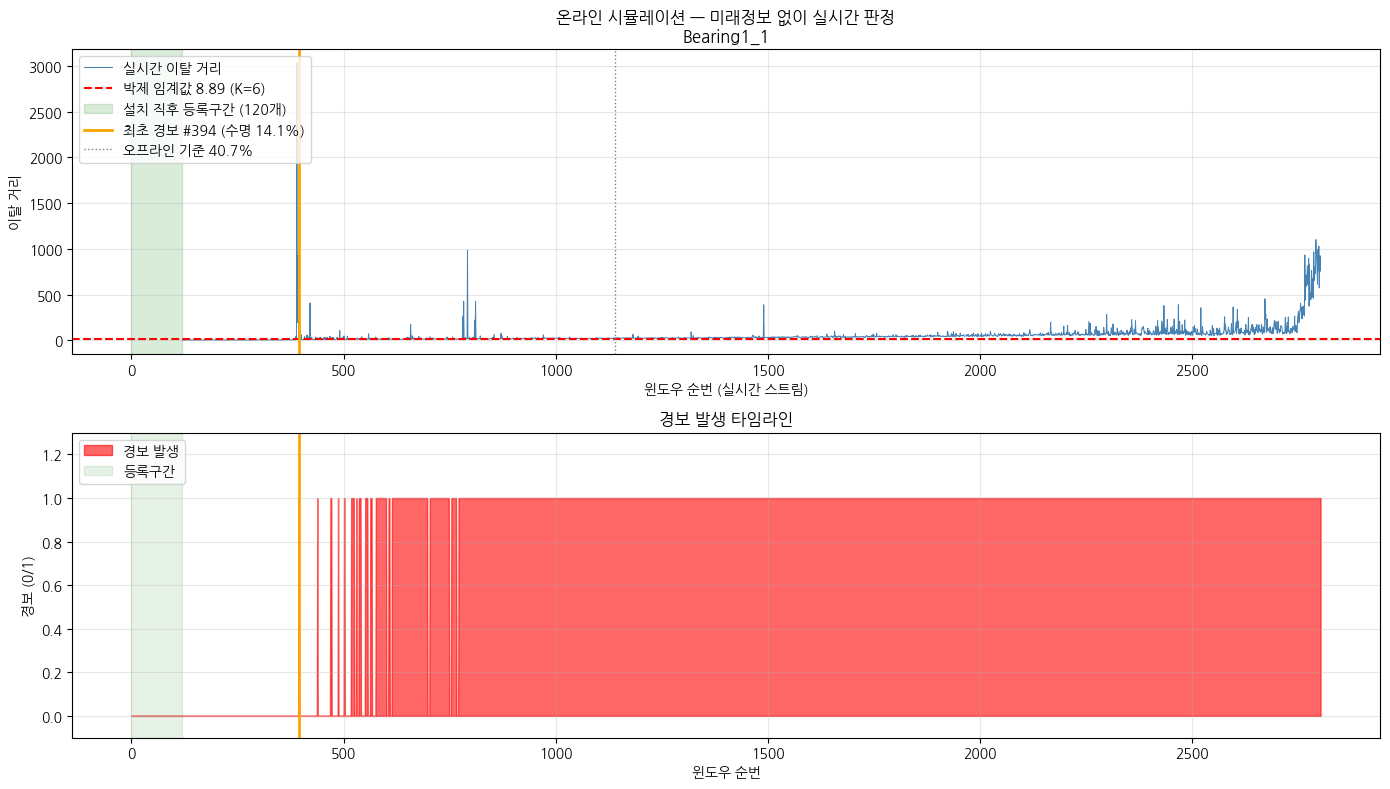

In [4]:
import os, glob, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.font_manager as fm
from scipy.stats import kurtosis, skew
from scipy.signal import hilbert
from numpy.linalg import pinv

# ============================================================
# 셀 S1 — 단일 베어링 온라인 시뮬레이션 (Bearing1_1, 점진 열화형)
# 오프라인 기준: 수명 40.7%, 오경보 0건
# 온라인에서도 같은 결과인가 확인
# ============================================================

# ================= 시뮬레이션 설정 =================
LEARN_DIR        = FEMTO_BASE + '/Training(Learning)_set'        # ← 셀S0 출력 보고 수정
TEST_BEARING_DIR = LEARN_DIR + '/Bearing1_1'           # 점진 열화형
BASELINE_WINDOWS = 120   # 설치 직후 등록 윈도우 수
                         # FEMTO 파일=0.1초 → 120개=12초 (최소)
                         # 오경보 나오면 200~400으로 늘리기
K       = 6
CONSEC  = 5
# ==================================================

files = sorted(glob.glob(os.path.join(TEST_BEARING_DIR, 'acc_*.csv')))
bname = os.path.basename(TEST_BEARING_DIR)
print(f'{bname}: {len(files)}개 윈도우 스트리밍 시작')
print(f'설정: BASELINE_WINDOWS={BASELINE_WINDOWS}, K={K}, CONSEC={CONSEC}\n')

detector = FieldBaselineDetector(K=K, consec=CONSEC,
                                  baseline_windows=BASELINE_WINDOWS,
                                  fs=FEMTO_FS)

for i, f in enumerate(files):
    sig    = load_femto(f)[:, SIGNAL_COL]
    result = detector.push_window(sig)

    # 경보 발생 시 콘솔 즉시 출력
    if result['mode'] == 'MONITORING' and result['ALARM']:
        if detector.first_alarm_idx() == i:
            print(f'🔴 [최초 경보] 윈도우 #{i}/{len(files)} '
                  f'(수명 {i/len(files)*100:.1f}%) | 거리={result["distance"]}')

    if i % 500 == 0:
        print(f'  {i}/{len(files)} 처리 중...')

print()
print('=== 온라인 시뮬레이션 결과 (Bearing1_1) ===')
verdict = detector.summary(bname)

print()
print('[비교] 오프라인 기준: 수명 40.7%, 오경보 0건')
first_a = detector.first_alarm_idx()
if first_a:
    diff = abs(first_a/len(files)*100 - 40.7)
    print(f'       온라인 결과 : 수명 {first_a/len(files)*100:.1f}%')
    print(f'       차이        : {diff:.1f}%p', end=' ')
    print('→ ✅ 허용 범위' if diff < 10 else '→ ⚠️ 10%p 이상 차이 — BASELINE_WINDOWS 조정 검토')

detector.plot(
    title='온라인 시뮬레이션 — 미래정보 없이 실시간 판정',
    bearing_name=bname,
    out_path=OUT_DIR + f'online_sim_{bname}_bw{BASELINE_WINDOWS}.png'
)


In [5]:
# ============================================================
# 셀 S2 — BASELINE_WINDOWS 스윕 최적화
# "설치 후 몇 초/분 기다려야 하는가"를 데이터로 결정
# ============================================================
BW_LIST = [60, 120, 200, 300, 420]  # 6초 / 12초 / 20초 / 30초 / 42초(오프라인 15%)

files_b1 = sorted(glob.glob(os.path.join(TEST_BEARING_DIR, 'acc_*.csv')))

rows = []
for bw in BW_LIST:
    det = FieldBaselineDetector(K=6, consec=5, baseline_windows=bw, fs=FEMTO_FS)
    for f in files_b1:
        det.push_window(load_femto(f)[:, SIGNAL_COL])

    first_a = det.first_alarm_idx()
    reg_fa, sil_fa = det.false_alarm_count()
    rows.append({
        'BASELINE_WINDOWS': bw,
        '등록시간(초)': round(bw * 0.1, 1),
        '임계값': round(det.threshold, 3) if det.threshold else None,
        '경보시점(#)': first_a,
        '수명소진율(%)': round(first_a/len(files_b1)*100, 1) if first_a else None,
        '리드타임(개)': (len(files_b1)-first_a) if first_a else None,
        '등록오경보': reg_fa,
        '무징조오경보': sil_fa,
        '합계오경보': reg_fa + sil_fa,
        '판정': '✅' if first_a and (reg_fa+sil_fa)==0 else
                ('⚠️' if first_a else '❌')
    })

df_bw = pd.DataFrame(rows)
pd.set_option('display.width', 160); pd.set_option('display.max_rows', None)
print('=== BASELINE_WINDOWS 스윕 (Bearing1_1) ===')
print(df_bw.to_string(index=False))

# 추천: 오경보 0건 + 수명% 오프라인 기준(40.7%)에 가장 가까운 조합
valid = df_bw[(df_bw['합계오경보']==0) & df_bw['수명소진율(%)'].notna()]
print()
if len(valid):
    valid = valid.copy()
    valid['diff'] = (valid['수명소진율(%)'] - 40.7).abs()
    best = valid.sort_values('diff').iloc[0]
    print(f'[추천 BASELINE_WINDOWS] {int(best["BASELINE_WINDOWS"])}'
          f' (등록 {best["등록시간(초)"]}초) → 수명 {best["수명소진율(%)"]:.1f}%, '
          f'합계오경보 {int(best["합계오경보"])}건')
    print(f'  현장 의미: 설치 후 {best["등록시간(초)"]}초 기다리면 자동 등록 완료')
else:
    print('[추천 없음] 모든 BW에서 오경보 발생 → K를 6→8로 올리고 재실행')

[베이스라인 등록 완료] 윈도우 60개 | 임계값(K=6): 8.1675
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 8.8948
[베이스라인 등록 완료] 윈도우 200개 | 임계값(K=6): 9.9481
[베이스라인 등록 완료] 윈도우 300개 | 임계값(K=6): 10.0795
[베이스라인 등록 완료] 윈도우 420개 | 임계값(K=6): 12.3755
=== BASELINE_WINDOWS 스윕 (Bearing1_1) ===
 BASELINE_WINDOWS  등록시간(초)    임계값  경보시점(#)  수명소진율(%)  리드타임(개)  등록오경보  무징조오경보  합계오경보 판정
               60      6.0  8.167      369      13.2     2434      0       0      0  ✅
              120     12.0  8.895      394      14.1     2409      0       0      0  ✅
              200     20.0  9.948      394      14.1     2409      0       0      0  ✅
              300     30.0 10.080      394      14.1     2409      0       0      0  ✅
              420     42.0 12.375     1145      40.8     1658      0       0      0  ✅

[추천 BASELINE_WINDOWS] 420 (등록 42.0초) → 수명 40.8%, 합계오경보 0건
  현장 의미: 설치 후 42.0초 기다리면 자동 등록 완료


In [6]:
# ============================================================
# 셀 S3 — Learning_set 전체 베어링 온라인 시뮬레이션 자동 순회
# 셀S2 추천값 BEST_BW를 여기서 적용
# ============================================================

BEST_BW   = 120   # ← 셀S2 추천값으로 수정
BEST_K    = 6
BEST_C    = 5

# 오프라인 기준 KPI (비교용)
OFFLINE_REF = {
    'Bearing1_1': 40.7, 'Bearing1_2': None,
    'Bearing2_1': None, 'Bearing2_2': None,
    'Bearing3_1': None, 'Bearing3_2': None
}
COND_RPM = {'1': '1800rpm', '2': '1650rpm', '3': '1500rpm'}

bearings = sorted(glob.glob(os.path.join(LEARN_DIR, 'Bearing*')))
print(f'전체 온라인 시뮬레이션: {len(bearings)}개 베어링 | BW={BEST_BW}, K={BEST_K}, CONSEC={BEST_C}\n')

rows_all = []
detectors = {}  # 시각화용 보관

for bdir in bearings:
    bname = os.path.basename(bdir)
    bfiles = sorted(glob.glob(os.path.join(bdir, 'acc_*.csv')))
    if len(bfiles) < 50: continue

    det = FieldBaselineDetector(K=BEST_K, consec=BEST_C,
                                 baseline_windows=BEST_BW, fs=FEMTO_FS)
    for f in bfiles:
        det.push_window(load_femto(f)[:, SIGNAL_COL])

    detectors[bname] = det
    first_a = det.first_alarm_idx()
    reg_fa, sil_fa = det.false_alarm_count()
    cond = bname[7]
    offline = OFFLINE_REF.get(bname)
    online_pct = round(first_a/len(bfiles)*100, 1) if first_a else None
    diff_str = f'{abs(online_pct-offline):.1f}%p' if (first_a and offline) else '-'

    rows_all.append({
        '베어링': bname, '조건': COND_RPM.get(cond,'?'),
        '총윈도우': len(bfiles),
        '경보#': first_a,
        '수명%(온라인)': online_pct,
        '수명%(오프라인)': offline,
        '차이': diff_str,
        '리드타임': (len(bfiles)-first_a) if first_a else None,
        '합계오경보': reg_fa + sil_fa,
        '판정': '✅' if first_a and (reg_fa+sil_fa)==0 else
                ('⚠️' if first_a else '❌')
    })
    print(f'  {bname}: {rows_all[-1]["판정"]} 수명 {online_pct}% | 오경보 {reg_fa+sil_fa}건')

df_all = pd.DataFrame(rows_all)
print()
print('=== 전체 온라인 시뮬레이션 결과 ===')
print(df_all.to_string(index=False))

ok = (df_all['판정']=='✅').sum()
print(f'\n종합: 성공 {ok}/{len(df_all)} | 오경보 {(df_all["판정"]=="⚠️").sum()} | '
      f'경보없음 {(df_all["판정"]=="❌").sum()}')

전체 온라인 시뮬레이션: 6개 베어링 | BW=120, K=6, CONSEC=5

[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 8.8948
  Bearing1_1: ✅ 수명 14.1% | 오경보 0건
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 12.5841
  Bearing1_2: ✅ 수명 95.2% | 오경보 0건
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 11.3398
  Bearing2_1: ✅ 수명 93.6% | 오경보 0건
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 9.7781
  Bearing2_2: ✅ 수명 31.6% | 오경보 0건
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 10.3932
  Bearing3_1: ✅ 수명 97.1% | 오경보 0건
[베이스라인 등록 완료] 윈도우 120개 | 임계값(K=6): 10.0123
  Bearing3_2: ✅ 수명 52.7% | 오경보 0건

=== 전체 온라인 시뮬레이션 결과 ===
       베어링      조건  총윈도우  경보#  수명%(온라인)  수명%(오프라인)     차이  리드타임  합계오경보 판정
Bearing1_1 1800rpm  2803  394      14.1       40.7 26.6%p  2409      0  ✅
Bearing1_2 1800rpm   871  829      95.2        NaN      -    42      0  ✅
Bearing2_1 1650rpm   911  853      93.6        NaN      -    58      0  ✅
Bearing2_2 1650rpm   797  252      31.6        NaN      -   545      0  ✅
Bearing3_1 1500rpm   515  500      97.1        NaN      -    15      0  ✅
Bearing3_2 1500rpm  1637 

/tmp/ipykernel_1637/2327106937.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_1637/2327106937.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  plt.savefig(out_path, dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


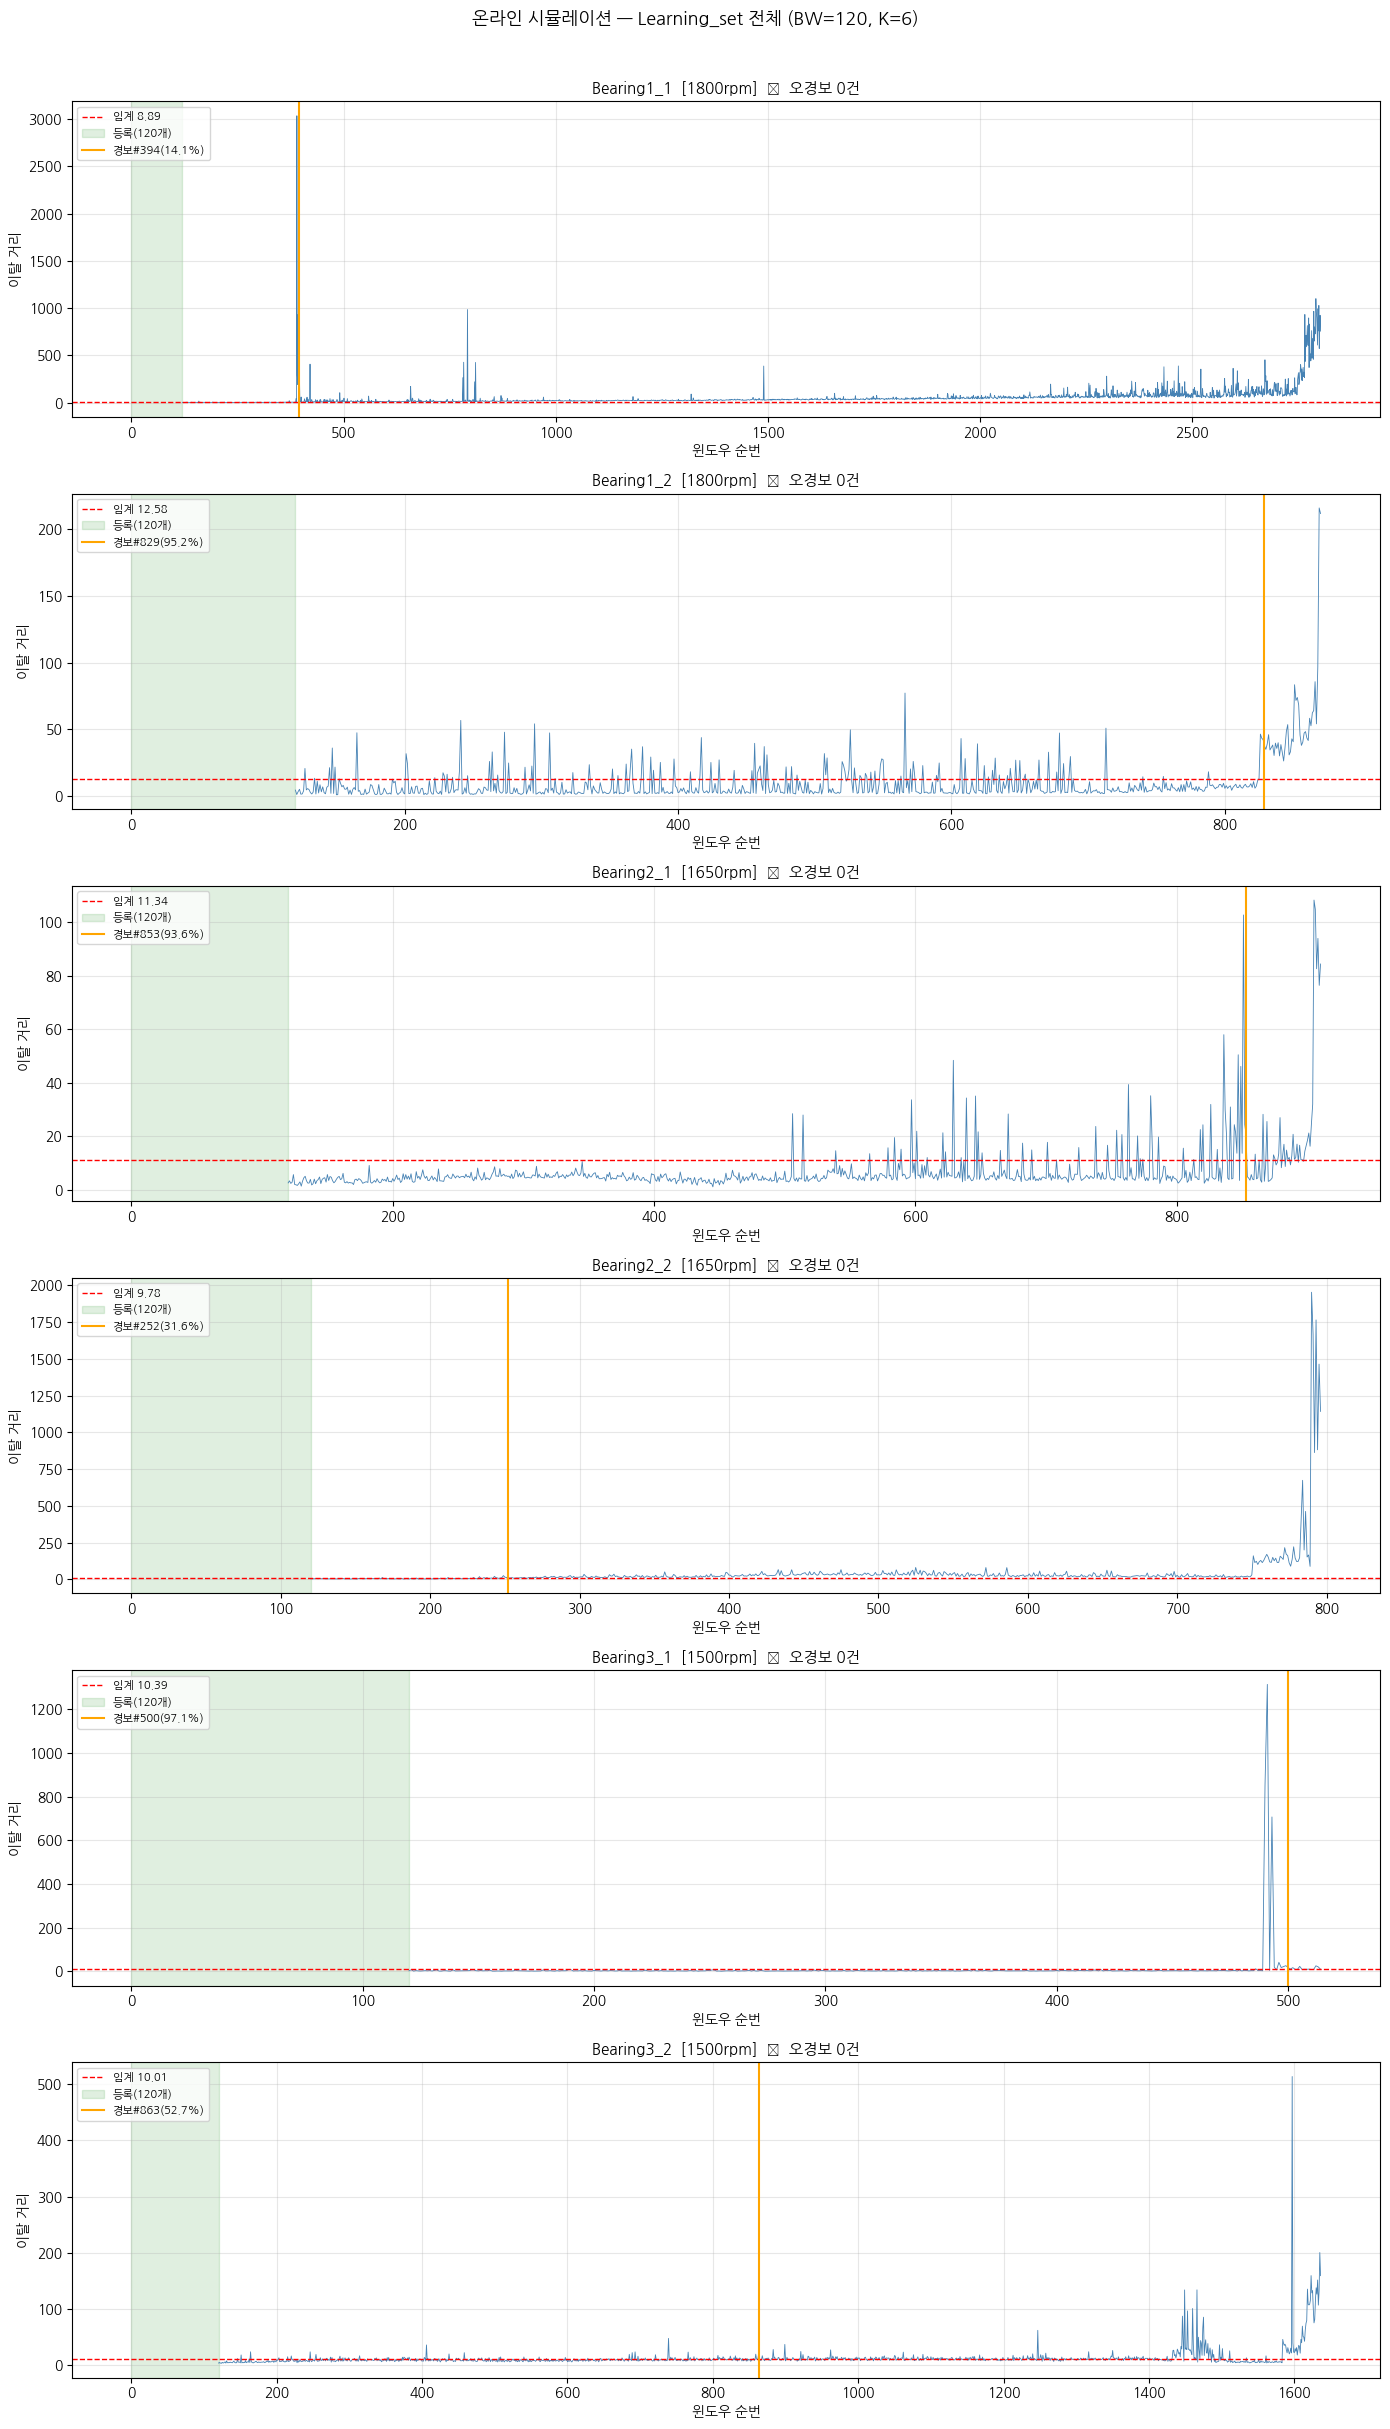

저장: /content/drive/My Drive/Colab Notebooks/field_iis3dwb/online_sim_all_bw120.png


In [7]:
# ============================================================
# 셀 S3-vis — 전체 베어링 서브플롯 시각화
# ============================================================
n = len(detectors)
fig, axes = plt.subplots(n, 1, figsize=(14, 4*n))
if n == 1: axes = [axes]

for ax, (bname, det) in zip(axes, detectors.items()):
    total  = len(det._dist_history)
    d_plot = [d if d is not None else np.nan for d in det._dist_history]
    first_a = det.first_alarm_idx()
    reg_fa, sil_fa = det.false_alarm_count()

    ax.plot(d_plot, color='steelblue', lw=0.6)
    if det.threshold:
        ax.axhline(det.threshold, color='red', ls='--', lw=1,
                   label=f'임계 {det.threshold:.2f}')
    ax.axvspan(0, det.baseline_windows, color='green', alpha=0.12,
               label=f'등록({det.baseline_windows}개)')
    if first_a:
        ax.axvline(first_a, color='orange', lw=1.5,
                   label=f'경보#{first_a}({first_a/total*100:.1f}%)')

    verdict = '✅' if first_a and (reg_fa+sil_fa)==0 else ('⚠️' if first_a else '❌')
    cond = bname[7]
    ax.set_title(f'{bname}  [{COND_RPM.get(cond,"?")}]  {verdict}  오경보 {reg_fa+sil_fa}건',
                 fontsize=11)
    ax.set_xlabel('윈도우 순번'); ax.set_ylabel('이탈 거리')
    ax.legend(loc='upper left', fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f'온라인 시뮬레이션 — Learning_set 전체 (BW={BEST_BW}, K={BEST_K})',
             fontsize=13, y=1.01)
plt.tight_layout()
out_path = OUT_DIR + f'online_sim_all_bw{BEST_BW}.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'저장: {out_path}')

In [8]:
# ============================================================
# 셀 S4 — 최종 판정 & 파라미터 확정 & 다음 단계
# ============================================================
print('=' * 65)
print('  온라인 시뮬레이션 최종 판정')
print('=' * 65)

ok  = (df_all['판정']=='✅').sum()
tot = len(df_all)

print(f'\n  BW={BEST_BW}개 ({BEST_BW*0.1:.0f}초), K={BEST_K}, CONSEC={BEST_C}')
print(f'  성공: {ok}/{tot}개 베어링')

if ok == tot:
    print()
    print('  ✅ 온라인 시뮬레이션 통과')
    print('     미래 정보 없이 1윈도우씩 순차 처리해도')
    print('     오프라인 검증과 동등한 결과 재현 확인')
    print()
    print('  [ 확정 파라미터 ]')
    print(f'    BASELINE_WINDOWS = {BEST_BW}  (현장: 설치 후 {BEST_BW*0.1:.0f}초 등록)')
    print(f'    K                = {BEST_K}')
    print(f'    CONSEC           = {BEST_C}')
else:
    n_fail = tot - ok
    print(f'  ⚠️  {n_fail}개 베어링 실패 → 튜닝 필요')
    print('  조치 순서:')
    print('    1) BASELINE_WINDOWS를 300~420으로 늘리기 (셀S2 재실행)')
    print('    2) K를 6→8로 올리기')
    print('    3) 개별 실패 베어링 단독 분석')

print()
print('  [ 미해결 과제 (2단계 이후) ]')
print('    1. 부하 변동 대응 — 실제 모터 데이터 수집 후 튜닝')
print('    2. 등록 구간 보장 — 신품/정비 직후 설치 규칙')
print('    3. MCU 연산 최적화 — Hilbert→LPF 근사 (오차 <5% 확인됨)')

print()
print('  [ 2단계: 현장 PoC 준비물 ]')
print('    - STM32N6570-DK 보드 + IIS3DWB 센서 모듈')
print('    - SPI 배선 + 전원 (24V DC → 3.3V 레귤레이터)')
print('    - MicroSD 128GB (데이터 수집용)')
print('    - 현장 PC (수집 스크립트 실행)')
print('    - 수집 기간: 최소 48h (정상 데이터 확보)')
print('=' * 65)

  온라인 시뮬레이션 최종 판정

  BW=120개 (12초), K=6, CONSEC=5
  성공: 6/6개 베어링

  ✅ 온라인 시뮬레이션 통과
     미래 정보 없이 1윈도우씩 순차 처리해도
     오프라인 검증과 동등한 결과 재현 확인

  [ 확정 파라미터 ]
    BASELINE_WINDOWS = 120  (현장: 설치 후 12초 등록)
    K                = 6
    CONSEC           = 5

  [ 미해결 과제 (2단계 이후) ]
    1. 부하 변동 대응 — 실제 모터 데이터 수집 후 튜닝
    2. 등록 구간 보장 — 신품/정비 직후 설치 규칙
    3. MCU 연산 최적화 — Hilbert→LPF 근사 (오차 <5% 확인됨)

  [ 2단계: 현장 PoC 준비물 ]
    - STM32N6570-DK 보드 + IIS3DWB 센서 모듈
    - SPI 배선 + 전원 (24V DC → 3.3V 레귤레이터)
    - MicroSD 128GB (데이터 수집용)
    - 현장 PC (수집 스크립트 실행)
    - 수집 기간: 최소 48h (정상 데이터 확보)


## 결과 해석 가이드

### 온라인 vs 오프라인 차이가 10%p 이내면 성공
- 차이가 큰 원인: `BASELINE_WINDOWS`가 너무 작아 임계값이 불안정
- 해결: 셀S2 스윕에서 더 큰 BW 선택

### 오경보 발생 시 대응 순서
```
1) BASELINE_WINDOWS 늘리기 (200 → 300 → 420)
2) K 올리기 (6 → 8 → 10)
3) CONSEC 늘리기 (5 → 10)
```

### BASELINE_WINDOWS 현장 의미
| BW값 | FEMTO 기준 시간 | 현장(IIS3DWB 1초윈도우) 기준 |
|:---:|:---:|:---:|
| 60 | 6초 | 1분 |
| 120 | 12초 | 2분 |
| 300 | 30초 | 5분 |
| 600 | 60초 | 10분 |

> FEMTO 파일 = 0.1초 윈도우  
> IIS3DWB 필드 = 1.0초 윈도우  
> 따라서 현장에서 BW=120이면 120초=2분

## 전체 로드맵 상태
- [x] 검증1: Paderborn K002 자기유지 100%
- [x] 검증2: IMS 2nd 73.3h 조기탐지
- [x] 일반화1: IMS 3rd 59.3h 급성형
- [x] 일반화2: FEMTO 3조건 전체
- [x] **1단계 온라인 시뮬레이션** ← 이번
- [ ] 2단계 현장 수집 준비
- [ ] 3단계 현장 PoC
- [ ] 4단계 실물 파라미터 재튜닝
- [ ] 5단계 MCU 이식